In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast

shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_store1.csv", index_col=0)
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates_store1.csv", index_col=0)
df = shop_sales.merge(shop_dates, on="date_id", how="left")
df = df[['item_id', 'date', 'cnt']]

In [3]:
horizon = 28
last_k_days = 56

multi_fc = MultiItemForecaster(model_name="ets")
multi_fc.fit(
    df,
    seasonal_periods=7,
    trend='add',
    seasonal='add',
)

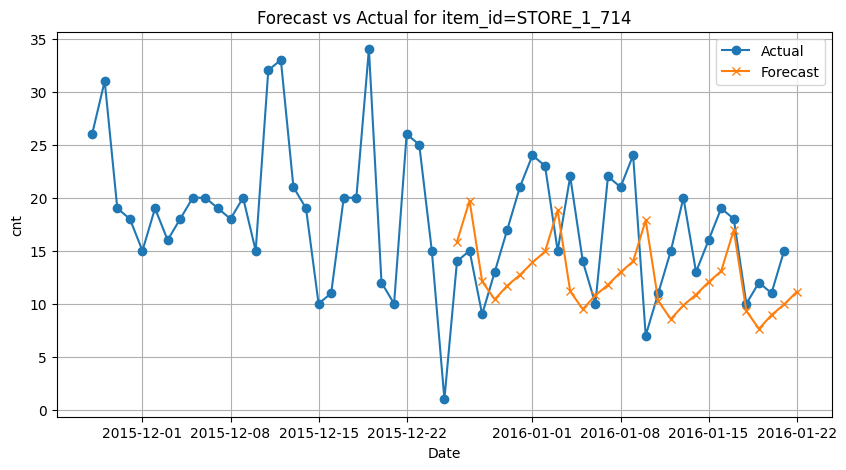

{'SMAPE': np.float64(93.8241905752586),
 'WAPE': np.float64(inf),
 'RMSE': np.float64(14.808455517061777),
 'MASE': np.float64(1.7813379641202765)}

In [ ]:


forecasts = multi_fc.predict(horizon=horizon)

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon)
plot_forecast(df, forecasts, item_id='STORE_1_714', horizon=horizon, last_k_days=last_k_days)

metrics_agg

In [4]:
metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon,)
# remove_cat
pd.DataFrame(metrics_agg.items()).T


,0,1,2,3,4,5
0,SMAPE,WAPE,RMSE,MASE,MAE,MAPE
1,0.938242,494616345.630073,14.808456,1.781338,12.217608,1627842916.246324


In [4]:
def plot_correlogram(series, lags=30):
    """
    series: pd.Series временного ряда
    lags: количество лагов для расчета ACF/PACF
    """
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plot_acf(series, lags=lags, ax=plt.gca())
    plt.title("ACF")
    
    plt.subplot(1,2,2)
    plot_pacf(series, lags=lags, ax=plt.gca())
    plt.title("PACF")
    
    plt.tight_layout()
    plt.show()


In [5]:
df.item_id.unique()

array(['STORE_1_046', 'STORE_1_033', 'STORE_1_043', 'STORE_1_090',
       'STORE_1_099', 'STORE_1_131', 'STORE_1_252', 'STORE_1_295',
       'STORE_1_304', 'STORE_1_491', 'STORE_1_542', 'STORE_1_555',
       'STORE_1_586', 'STORE_1_587', 'STORE_1_714'], dtype=object)

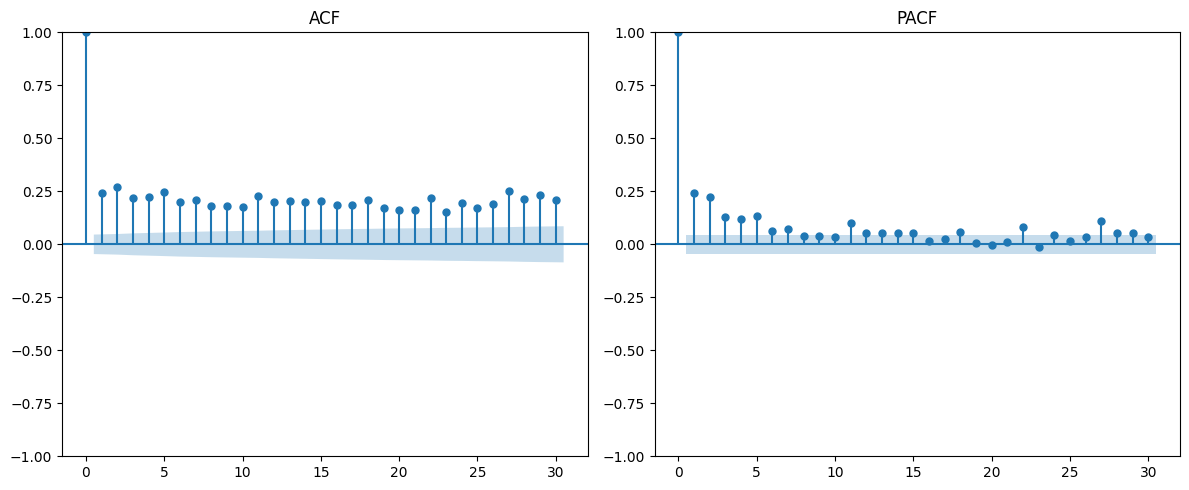

In [20]:
series_item3 = df[df['item_id'] == 'STORE_1_043'].sort_values('date')['cnt']

plot_correlogram(series_item3, lags=30)


In [7]:
series = series_item3

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# series — pd.Series с индексом pd.DatetimeIndex
model = ExponentialSmoothing(series,
                             trend='add',        # 'add' или 'mul' или None
                             seasonal='add',     # 'add' или 'mul' или None
                             seasonal_periods=7) # длина сезона
fit = model.fit()


c:\Users\makanov.artem\Desktop\ВР\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [14]:
import itertools
import numpy as np

best_aic = np.inf
best_params = None

for trend, seasonal, period in tqdm(list(itertools.product([None,'add','mul'], [None,'add','mul'], [7,30,90]))):
    if trend is None and seasonal is None:
        continue  # нужно хотя бы что-то
    try:
        fit = ExponentialSmoothing(series, trend=trend, seasonal=seasonal, seasonal_periods=period).fit()
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_params = (trend, seasonal, period)
    except:
        continue

print("Best ETS parameters:", best_params, "AIC:", best_aic)


  0%|          | 0/27 [00:00<?, ?it/s]c:\Users\makanov.artem\Desktop\ВР\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
 15%|█▍        | 4/27 [00:00<00:00, 25.94it/s]c:\Users\makanov.artem\Desktop\ВР\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\makanov.artem\Desktop\ВР\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\makanov.ar

Best ETS parameters: (None, 'add', 7) AIC: 8260.406645264899
